# NNLF

In [1]:
######### LIBRARIES ############
# RICORDA DI ELIMINARE TUTTE LIBRERIE CHE NON UTILIZZI
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
########################     PREPARATION      ##########################
Nlf_models = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases_new/N_bases.txt").astype(int)   #list of number of bases
U_train_LF_full = np.abs(np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases_new/Ulf_train.txt"))


n_bases = U_train_LF_full.shape[1]                                # <--------
m = list(Nlf_models).index(n_bases)     # maximal nb. of basis

In [3]:
#########################     TRAIN SET      ##########################
mu_train_LF = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases_new/mu_train_LF.txt")
Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN
# ADD NOISE

permutation = np.random.permutation(len(mu_train_LF))
mu_train_LF=mu_train_LF[permutation][0:10]
Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN


#noise_stddev = np.mean(U_train_LF_full)*0.1
#noise = np.random.normal(0, noise_stddev, np.shape(U_train_LF_full))
#U_train_LF_full=U_train_LF_full+noise

#noise_stddev = np.mean(mu_train_LF)*0.1
#noise = np.random.normal(0, noise_stddev, len(mu_train_LF))
#mu_train_LF=mu_train_LF+noise


m=0
U_lf_train = U_train_LF_full[:,m]
U_lf_train=U_lf_train[permutation][0:10]

NepoLF = 3000                          # number of epochs for first NN: NN_LF

In [4]:
#########################     TEST SET      ##########################
mu_test = np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases_new/mu_test.txt")
N_test = np.size(mu_test)
# provo ad aggiungere noise anche qua, anche se pèrobabilmente innecessario 
#noise = np.random.normal(0, noise_stddev, len(mu_test))
#mu_test=mu_test+noise

U_lf_test_full = np.abs(np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases_new/Ulf_test.txt"))
U_lf_test = U_lf_test_full[:,m]

# ADD NOISE
#noise = np.random.normal(0, noise_stddev, len(mu_test))
#mu_test=mu_test+noise

In [5]:
########################     NORMALIZATION  #########################
#Input
mu_max = np.max(mu_test,axis=0)
mu_min = np.min(mu_test,axis=0)

mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_train_LF_norm = (mu_train_LF - mu_min) / (mu_max - mu_min)

#Output

U_t_max_train=np.max(U_lf_train)
U_t_min_train=np.min(U_lf_train)

U_t_max_test=np.max(U_lf_test)
U_t_min_test=np.min(U_lf_test)

U_lf_train=(U_lf_train-U_t_min_train)/(U_t_max_test-U_t_min_test)
U_lf_test=(U_lf_test-U_t_min_test)/(U_t_max_test-U_t_min_test)

start = perf_counter()
#########
mu_final = np.vstack((mu_train_LF_norm))#.transpose() # <- TRAINING INPUT for the second NN: NN_HF
########

In [6]:
##########################       NN_LF     ##########################
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 2
name = 'LF'
K.clear_session()
bayes_trials = Trials()
opt_list = ['Adam','Adamax']
kernel_list = ['uniform','glorot_uniform']
aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
space = {
    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(64),2),
     'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(100)),
     'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
     'kernel_init': hp.choice('kernel_init',kernel_list),
     'opt' : hp.choice('opt',opt_list)}

def objective(params):
    K.clear_session()
    CVres = kCrossVal(np.shape(mu_final)[1],Nlf,NepoLF,mu_final, U_lf_train,params,name)
    return {'loss' : CVres, 'params':params, 'status': STATUS_OK}

best_params = fmin(fn = objective,
                   space = space,
                   algo = tpe.suggest,
                   max_evals = MAX_EVAL,
                   trials = bayes_trials)

transfBestparam(best_params,aux_dic)
print(best_params)

  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

1/1 [==============================] - 0s 117ms/step

1/1 [==============================] - 0s 30ms/step 

1/1 [==============================] - 0s 33ms/step 

1/1 [==============================] - 0s 34ms/step 

1/1 [==============================] - 0s 29ms/step 

1/1 [==============================] - 0s 34ms/step 

1/1 [==============================] - 0s 33ms/step 

1/1 [==============================] - 0s 33ms/step 

1/1 [==============================] - 0s 33ms/step 

1/1 [==============================] - 0s 29ms/step 

1/1 [==============================] - 0s 77ms/step                               

1/1 [==============================] - 0s 28ms/step                               

1/1 [==============================] - 0s 33ms/step                               

1/1 [==============================] - 0s 34ms/step                               

1/1 [==============================] - 0s 27ms/step                               

1/1 [==============================] - 0

In [7]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()
finalModel = getModel(best_params,name) #final model chosen according to the best paramters
hist = finalModel.fit(mu_train_LF_norm, U_lf_train, validation_data=(mu_test_norm, U_lf_test),epochs=NepoLF,batch_size=Nlf,verbose=0, validation_freq = 20)

ULF = finalModel.predict(mu_test_norm)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)
print('\nLF Model:')

elapsed2 = stop - start2
print('Elapsed time: ', elapsed2)
print('\nLF Model:')

test_mse = np.mean(np.square(U_lf_test - ULF[:,0]))
print(f"Test MSE: {test_mse}")

r2_LF = 1 - np.sum(np.square(U_lf_test - ULF[:,0])) / np.sum(np.square(U_lf_test - np.mean(U_lf_test)))
print(f"R^2: {r2_LF}")

print('Number of basis functions: ', int(Nlf_models[m]))

16/16 [==============================] - 0s 3ms/step
Elapsed time:  267.6866289000027

LF Model:
Elapsed time:  21.55981939996127

LF Model:
Test MSE: 0.0028323566699615214
R^2: 0.9523078755264713
Number of basis functions:  1


In [8]:
####################    NN training and PREDICTION HF   #######################
#start2 = perf_counter()
finalModel = getModel(best_params,name) #final model chosen according to the best paramters
#noise = np.random.normal(0, noise_stddev, len(mu_test))

#mu_test=mu_test+noise
#mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_test2 = np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases_new/mu_test.txt")
#N_test = np.size(mu_test)
#mu_test=build_poly(mu_test,3)
U_hf_test = np.abs(np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases_new/Uhf_test.txt"))

mu_max = np.max(mu_test2,axis=0)
mu_min = np.min(mu_test2,axis=0)

mu_test2_norm = (mu_test2 - mu_min) / (mu_max - mu_min)


U_hf_test=(U_hf_test-np.min(U_hf_test))/(np.max(U_hf_test)-np.min(U_hf_test))

#hfmean = np.mean(U_hf_test)

#U_hf_test = U_hf_test - hfmean


hist = finalModel.fit(mu_train_LF_norm, U_lf_train, validation_data=(mu_test2_norm, U_hf_test),epochs=NepoLF,batch_size=Nlf,verbose=0, validation_freq = 20)

UHF = finalModel.predict(mu_test2_norm)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)
print('\nLF Model:')

elapsed2 = stop - start2
print('Elapsed time: ', elapsed2)
print('\nLF Model:')

test_mse_HF = np.mean(np.square(U_hf_test - UHF[:,0]))
print(f"Test MSE: {test_mse_HF}")

r2_HF = 1 - np.sum(np.square(U_hf_test - UHF[:,0])) / np.sum(np.square(U_hf_test - np.mean(U_hf_test)))
print(f"R^2: {r2_HF}")

print('Number of basis functions: ', int(Nlf_models[m]))

16/16 [==============================] - 0s 2ms/step
Elapsed time:  293.63100900000427

LF Model:
Elapsed time:  47.50419949996285

LF Model:
Test MSE: 0.0006523232173577997
R^2: 0.9877047551922055
Number of basis functions:  1


16/16 [==============================] - 0s 3ms/step


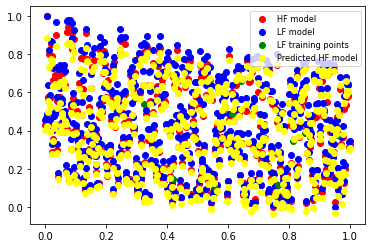

16/16 [==============================] - 0s 3ms/step


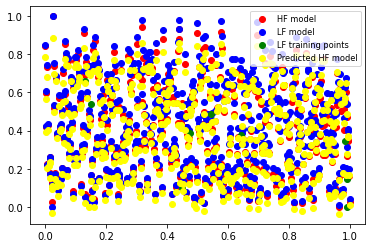

16/16 [==============================] - 0s 4ms/step


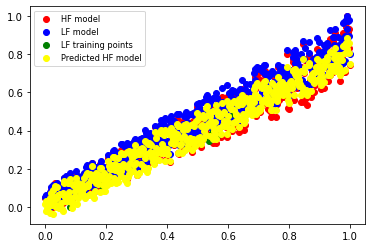

In [9]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.scatter(mu_test2_norm[:,0], U_hf_test,color='red', label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.scatter(mu_test_norm[:,0], U_lf_test,color='blue', label = 'LF model')
plt.scatter(mu_train_LF_norm[:,0], U_lf_train,color='green', label = 'LF training points')
plt.scatter(mu_test2_norm[:,0], finalModel.predict(mu_test2_norm),color='yellow',  label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

plt.figure()
plt.scatter(mu_test2_norm[:,1], U_hf_test,color='red', label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.scatter(mu_test_norm[:,1], U_lf_test,color='blue', label = 'LF model')
plt.scatter(mu_train_LF_norm[:,1], U_lf_train,color='green', label = 'LF training points')
plt.scatter(mu_test2_norm[:,1], finalModel.predict(mu_test2_norm),color='yellow',  label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

plt.figure()
plt.scatter(mu_test2_norm[:,2], U_hf_test,color='red', label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.scatter(mu_test_norm[:,2], U_lf_test,color='blue', label = 'LF model')
plt.scatter(mu_train_LF_norm[:,2], U_lf_train,color='green', label = 'LF training points')
plt.scatter(mu_test2_norm[:,2], finalModel.predict(mu_test2_norm),color='yellow',  label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

In [11]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs('Output_NNLF_new2')

R2_HF=pandas.DataFrame({'R2_HF': [r2_HF]})
R2_LF=pandas.DataFrame({'R2_LF': [r2_LF]})
MSE_test_LF=pandas.DataFrame({'MSE_test_LF': [test_mse]})
MSE_test_HF=pandas.DataFrame({'MSE_test_HF': [test_mse_HF]})


R2_LF.to_csv('./Output_NNLF_new2/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv('./Output_NNLF_new2/test_mse.txt', header = True, index = False, sep = '\t', mode = 'a')
R2_HF.to_csv('./Output_NNLF_new2/r2_LF_lhs.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_LF.to_csv('./Output_NNLF_new2/mse_LF_lhs.txt', header = True, index = False, sep = '\t', mode = 'a')